In [13]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

## Trực quan phân phối số lượng của các event

### Config & Code

In [14]:
def plot_event_type_counts(jsonl_path: str | Path, all_events: list[str] | None = None, figsize: tuple = (12, 6)) -> None:
    """
    - Summary: Vẽ bar chart số lượng theo từng loại sự kiện.
    - Args:
        - jsonl_path: Đường dẫn file JSONL đã format (có field "events").
        - all_events: List đầy đủ tên event_type cần luôn hiển thị (kể cả khi bằng 0).
        - figsize:    Kích thước biểu đồ (width, height).
    - Output:
        - None. Hiển thị bar chart số lượng theo từng loại sự kiện.
    """
    # Bảng màu tham chiếu (dataviz skill — references/palette.md)
    ink_primary   = "#0b0b0b"
    ink_secondary = "#52514e"
    ink_muted     = "#898781"
    gridline      = "#e1e0d9"
    baseline      = "#c3c2b7"
    surface       = "#fcfcfb"
    seq_blue      = "#2a78d6"  # sequential hue — dùng cho series đơn

    records: list[dict] = []
    with Path(jsonl_path).open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except Exception:
                    pass

    counts = Counter()
    for record in records:
        for event in record.get("events") or []:
            counts[event.get("event_type", "UNKNOWN")] += 1
    for event_type in all_events or []:
        counts.setdefault(event_type, 0)

    sorted_items   = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    labels, values = zip(*sorted_items) if sorted_items else ([], [])

    fig, ax = plt.subplots(figsize=figsize)
    bars    = ax.bar(range(len(labels)), values, color=seq_blue, width=0.6)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value),
                 ha='center', va='bottom', fontsize=9, color=ink_secondary)

    ax.set_facecolor(surface)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(baseline)
    ax.yaxis.grid(True, color=gridline, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=ink_muted, labelsize=9)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Số lượng sự kiện', color=ink_secondary)
    ax.set_title(f'Số lượng theo loại sự kiện — {Path(jsonl_path).name}', color=ink_primary, fontsize=12)

    fig.tight_layout()
    plt.show()

In [15]:
all_events = [
    "Chi trả cổ tức",
    "Phát hành thêm cổ phiếu",
    "Chia tách cổ phiếu",
    "Gộp cổ phiếu",
    "Niêm yết",
    "Hủy niêm yết",
    "Chuyển sàn",
    "Phát hành trái phiếu",
    "Cổ đông thay đổi tỷ lệ sở hữu",
    "Cổ đông cầm cố cổ phiếu",
    "Cổ đông phong tỏa cổ phiếu",
    "Thay đổi nhân sự chủ chốt",
    "Lãnh đạo cấp cao qua đời",
    "M&A",
    "Đầu tư",
    "Hợp đồng lớn",
    "Vay vốn",
    "Tổn thất tài sản nghiêm trọng",
    "Bồi thường lớn cho bên ngoài",
    "Vấn đề pháp lý với tổ chức",
    "Vấn đề pháp lý với cá nhân",
    "Phá sản",
]
len(all_events)

22

### Run

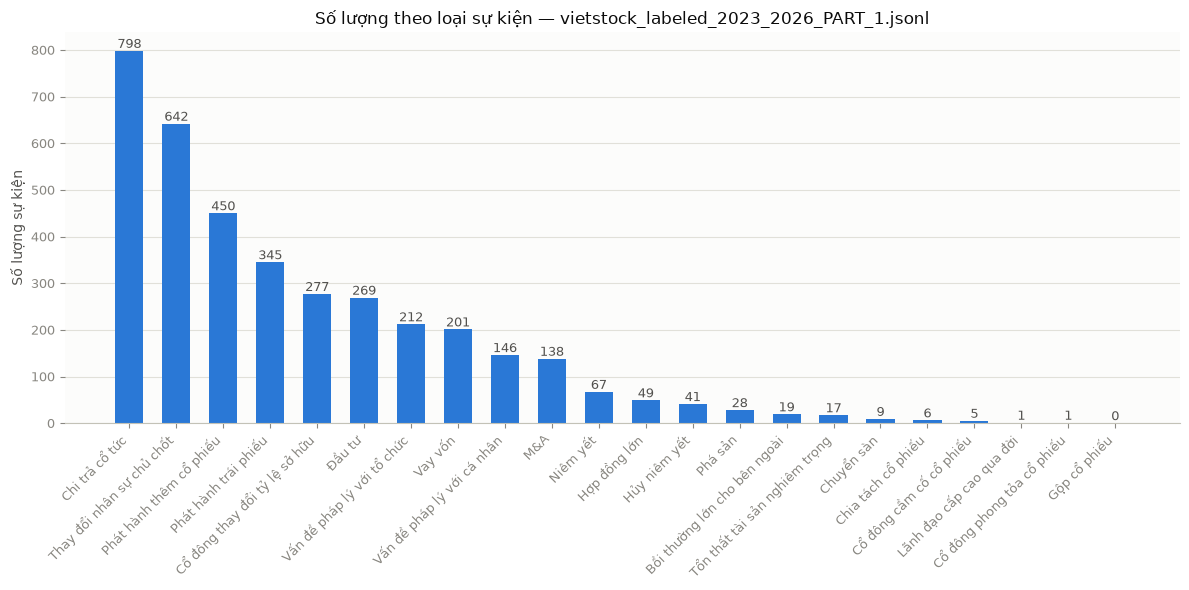

In [16]:
PROJECT_DIR  = Path.cwd().parent
SAMPLE_FILE  = PROJECT_DIR / "data/processing/label/prompt1/vietstock_labeled_2023_2026_PART_1.jsonl"

plot_event_type_counts(SAMPLE_FILE, all_events=all_events)

## So sánh số lượng mẫu có sự kiện và không có sự kiện

### Config & Code

In [17]:
def plot_event_vs_no_event_counts(jsonl_path: str | Path, figsize: tuple = (5, 5.5)) -> None:
    """
    - Summary: Vẽ bar chart so sánh mẫu có/không có sự kiện.
    - Args:
        - jsonl_path: Đường dẫn file JSONL đã format (có field "events").
        - figsize:    Kích thước biểu đồ (width, height).
    - Output:
        - None. Hiển thị bar chart so sánh mẫu có/không có sự kiện.
    """
    # Bảng màu tham chiếu (dataviz skill — references/palette.md)
    ink_primary   = "#0b0b0b"
    ink_secondary = "#52514e"
    ink_muted     = "#898781"
    gridline      = "#e1e0d9"
    baseline      = "#c3c2b7"
    surface       = "#fcfcfb"
    seq_blue      = "#2a78d6"  # categorical slot 1
    cat_aqua      = "#1baf7a"  # categorical slot 2

    records: list[dict] = []
    with Path(jsonl_path).open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except Exception:
                    pass

    has_event_count = sum(1 for record in records if record.get("events"))
    no_event_count  = len(records) - has_event_count

    labels = ['Có ít nhất 1 sự kiện', 'Không có sự kiện']
    values = [has_event_count, no_event_count]
    colors = [seq_blue, cat_aqua]

    fig, ax = plt.subplots(figsize=figsize)
    bars    = ax.bar(labels, values, color=colors, width=0.5)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value),
                 ha='center', va='bottom', fontsize=10, color=ink_secondary)

    ax.set_facecolor(surface)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(baseline)
    ax.yaxis.grid(True, color=gridline, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=ink_muted, labelsize=9)

    ax.set_ylabel('Số lượng mẫu', color=ink_secondary)
    ax.set_title(f'Mẫu có/không có sự kiện — {Path(jsonl_path).name}', color=ink_primary, fontsize=12)

    fig.tight_layout()
    plt.show()

### Run

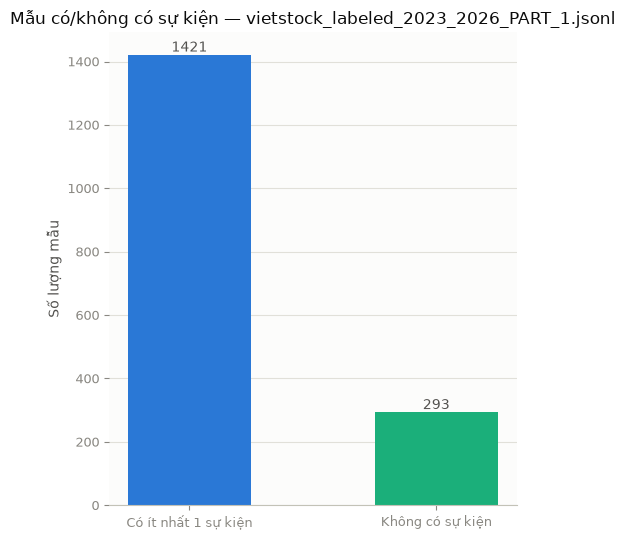

In [18]:
PROJECT_DIR  = Path.cwd().parent
SAMPLE_FILE  = PROJECT_DIR / "data/processing/label/prompt1/vietstock_labeled_2023_2026_PART_1.jsonl"

plot_event_vs_no_event_counts(SAMPLE_FILE)